#  Preliminaries

Import libraries:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import scipy as sp
import seaborn as sns

Import data:

In [2]:
data = pd.read_csv('bugfixes.csv', sep = " ")
data

,dauer,programmierer,bugtyp,codelines,usecases,alter
0,120,Eckkrammer,GUI,183000,49,35
1,174,Meyer,DB,386000,86,44
2,188,Meyer,GUI,467000,95,37
3,161,Mandl,GUI,309000,70,35
4,157,Eckkrammer,Reporting,305000,71,21
5,178,Meyer,Reporting,243000,85,36
6,143,Eckkrammer,GUI,361000,81,34
7,184,Mandl,Reporting,228000,57,40
8,159,Eckkrammer,Reporting,203000,61,29
9,178,Mandl,DB,413000,77,32


In [3]:
# see slide 13

# turn of warnings
import warnings
warnings.filterwarnings('ignore')

data[data['codelines']>330000][data['codelines']<370000]

,dauer,programmierer,bugtyp,codelines,usecases,alter
6,143,Eckkrammer,GUI,361000,81,34
10,157,Eckkrammer,DB,365000,80,34
14,189,Mandl,DB,364000,73,25
16,174,Meyer,Reporting,348000,73,47


In [4]:
data[data['codelines']>500000]

,dauer,programmierer,bugtyp,codelines,usecases,alter
15,176,Mandl,Reporting,521000,97,22
20,207,Meyer,GUI,517000,91,39


In [5]:
data.shape

(21, 6)

In [6]:
data.isna().any()

dauer            False
programmierer    False
bugtyp           False
codelines        False
usecases         False
alter            False
dtype: bool

In [7]:
data.sort_values('codelines', inplace = True)
data.head()

,dauer,programmierer,bugtyp,codelines,usecases,alter
0,120,Eckkrammer,GUI,183000,49,35
8,159,Eckkrammer,Reporting,203000,61,29
7,184,Mandl,Reporting,228000,57,40
5,178,Meyer,Reporting,243000,85,36
4,157,Eckkrammer,Reporting,305000,71,21


**Summary:**

The data set consists of 21 observations and 6 variables. `dauer`, `bugtyp`, `usecases` and `alter` are numeric, `programmierer` and `bugtyp` are categorical. No values are missing.

# Data Exploration

Visualize `dauer` and `codelines` using histograms and kernel density estimates:

<AxesSubplot:xlabel='dauer', ylabel='Density'>

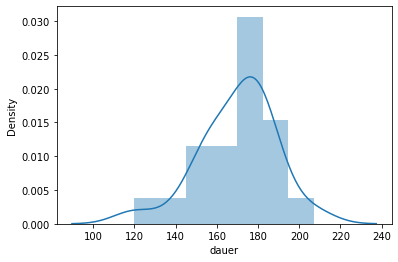

In [8]:
sns.distplot(data.dauer)

<AxesSubplot:xlabel='codelines', ylabel='Density'>

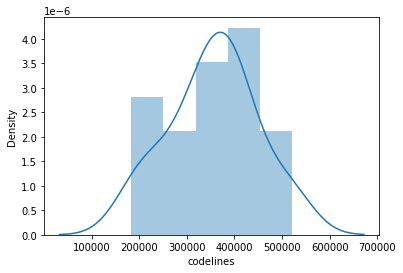

In [9]:
sns.distplot(data.codelines)

Both distributions are slightly left-skewed, codelines is multimodal.

In [10]:
data.describe()

,dauer,codelines,usecases,alter
count,21.000000,21.000000,21.000000,21.000000
mean,169.809524,355285.714286,77.476190,34.904762
std,18.613487,92333.170019,11.948301,7.147760
min,120.000000,183000.000000,49.000000,21.000000
25%,159.000000,305000.000000,73.000000,31.000000
50%,174.000000,364000.000000,79.000000,35.000000
75%,178.000000,401000.000000,85.000000,39.000000
max,207.000000,521000.000000,97.000000,47.000000


In [11]:
# mean absolute deviaten
data.mad()

dauer           14.331066
codelines    71197.278912
usecases         9.024943
alter            5.442177
dtype: float64

`codelines` has a median of 364000 and a medmed of 71197. `dauer` has a median of 174 and a medmed of 14.33. The non-robust statistics (mean, standard deviation) are distorted by the skewness of the distributions.

# Correlation analysis

Scatter plot to visualize the relationship of `dauer` and `codelines`:

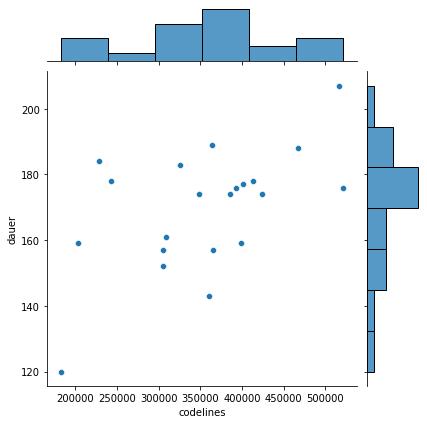

In [12]:
sns.jointplot(data.codelines, data.dauer)

Calculation of Pearson's correlation coefficient (along with P-value for significance test):

In [13]:
sp.stats.pearsonr(data.codelines, data.dauer)

(0.551980569890337, 0.009477327365881225)

The value is significant at the 0.05 level. Plot and correlation statistic suggest an average correlation of `dauer` and `codelines`.

Spearman's rank correlation coefficient:

In [14]:
sp.stats.spearmanr(data.codelines, data.dauer)

SpearmanrResult(correlation=0.4164777996108111, pvalue=0.06037573784499052)

The more robust rank correlation coefficient is **not** significant at the 0.05 level. Maybe the two extreme values in the bottom left and top right corners are outliers?

# Regression analysis

## Fitting a linear model

In [15]:
# ols .. ordinary least square model
model = smf.ols(formula = "dauer ~ codelines", data = data).fit()

In [16]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  dauer   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.268
Method:                 Least Squares   F-statistic:                     8.326
Date:                Thu, 22 Apr 2021   Prob (F-statistic):            0.00948
Time:                        14:55:57   Log-Likelihood:                -86.871
No. Observations:                  21   AIC:                             177.7
Df Residuals:                      19   BIC:                             179.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    130.2755     14.135      9.216      0.000     100.690     159.861
codelines      0.0001   3.86e-05      2.885      0.009    3.06e-05       0.000
==============================================================================
Omnibus:                        0.126   Durbin-Watson:                   1.995
Prob(Omnibus):                  0.939   Jarque-Bera (JB):                0.303
Skew:                          -0.141   Prob(JB):                        0.860
Kurtosis:                       2.484   Cond. No.                     1.49e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.49e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Both parameters (`codelines` and the intercept) are significant at the 0.05 level. The overall model is also significant. The R-squared indicates that the model explains about 30% of the variance of `dauer`.

Confidence intervals for the parameters:

In [17]:
model.conf_int()

,0,1
Intercept,100.690316,159.860590
codelines,0.000031,0.000192


## Regression Formula

E(dauer|codelines) = 130.27 + 0.0001 x codelines

To fix a bug, on the average, at least 130 minutes are required. For every 10.000 codelines, 1 minute is added.

## Regression plot

In [18]:
from statsmodels.stats.outliers_influence import summary_table
st, res, ss2 = summary_table(model)
st

Obs,Dep Var,Predicted,Std Error,Mean ci,Mean ci,Predict ci,Predict ci,Residual,Std Error,Student,Cook's
,Population,Value,Mean Predict,95% low,95% upp,95% low,95% upp,,Residual,Residual,D
1.0,120.0,150.63859932515496,7.497924395446367,134.94526320735116,166.33193544295875,113.79906426063519,187.47813438967472,-30.638599325154956,14.048527983347418,-2.180911719823797,0.6774334685021365
2.0,159.0,152.86407977939348,6.8238416149370495,138.5816151358581,167.14654442292886,116.60309052706538,189.12506903172158,6.135920220606522,14.388022600516672,0.42646028512536405,0.02045421627423402
3.0,184.0,155.6459303471916,6.014178675184565,143.0581097125211,168.23375098186213,120.0183599333358,191.27350076104742,28.35406965280839,14.744818194934805,1.9229853686869256,0.30760668738334423
4.0,178.0,157.3150406878705,5.552115262783908,145.69432989001652,168.93575148572447,122.01756960691378,192.6125117688272,20.684959312129507,14.924946393454391,1.385931899976624,0.13290617939005067
5.0,157.0,164.21403009600988,3.979428680443594,155.8849901450393,172.54307004698046,129.8593586266379,198.56870156538184,-7.214030096009878,15.418954443022011,-0.4678676574775571,0.007290337837484766
6.0,152.0,164.21403009600988,3.979428680443594,155.8849901450393,172.54307004698046,129.8593586266379,198.56870156538184,-12.214030096009878,15.418954443022011,-0.7921438604118485,0.020898240660957645
7.0,161.0,164.65912618685758,3.9065801301279186,156.48256000402648,172.83569236968867,130.34110206241485,198.9771503113003,-3.659126186857577,15.437572361793643,-0.23702730591977836,0.0017988801350330187
8.0,183.0,166.5507845729603,3.653866524344866,158.9031540459094,174.19841510001123,132.35492520458212,200.7466439413385,16.44921542703969,15.499331216571804,1.0612854965930578,0.03129780653541025
9.0,174.0,168.99881307262268,3.486284776419217,161.70193517505993,176.29569097018543,134.87968394663886,203.1179421986065,5.001186927377319,15.537883613814104,0.32187053601888005,0.0026078009649313175


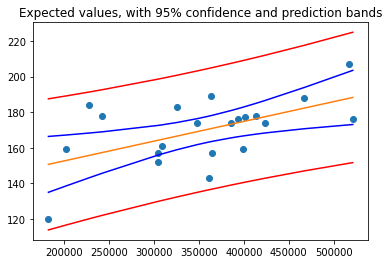

In [19]:
fittedvalues = res[:,2]
predict_mean_ci_low, predict_mean_ci_upp = res[:,4:6].T
predict_ci_low, predict_ci_upp = res[:,6:8].T

#Plot confidence intervals and data points
plt.title("Expected values, with 95% confidence and prediction bands")
plt.plot(data.codelines, data.dauer, 'o')
plt.plot(data.codelines, fittedvalues, '-')
plt.plot(data.codelines, predict_ci_low, 'r-')
plt.plot(data.codelines, predict_ci_upp, 'r-')
plt.plot(data.codelines, predict_mean_ci_low, 'b-')
plt.plot(data.codelines, predict_mean_ci_upp, 'b-')
#plt.savefig('regression_plot.pdf')

## Residual diagnostics

The above mentioned significance tests are only valid if certain assumptions are fulfilled.

### Normality of residuals

If the sample size is small (rule of thumb: N < 70), then the residuals (= observed - expected values) have to follow a normal distribution. This can be checked usind a Q-Q-Plot comparing the empirical quantiles of the residuals with the quantiles of a normal distribution. All points should be more or less on a straight line, especially at the ends.

In [20]:
from statsmodels.graphics.gofplots import qqplot

[-30.63859933   6.13592022  28.35406965  20.68495931  -7.2140301
 -12.2140301   -3.65912619  16.44921543   5.00118693 -27.44537537
  18.22080256 -13.89047146   0.77277406   1.99385591 -15.67378823
   2.10366372   1.76837545  -3.4556388    5.75957822  19.19587709
 -12.249219  ]


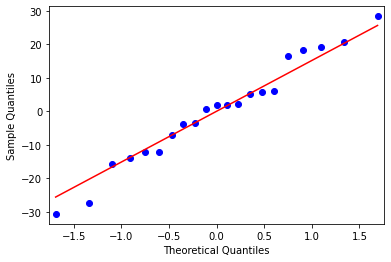

In [21]:
residuals = res[:,8]
print(residuals)
fig = qqplot(residuals, line = 's')

The plot basically looks OK, except the two points in the lower left part.

### Remaining structure in residuals

If the model fits well, the residuals really should just be noise, so there should be no correlation between the fitted values and the residuals:

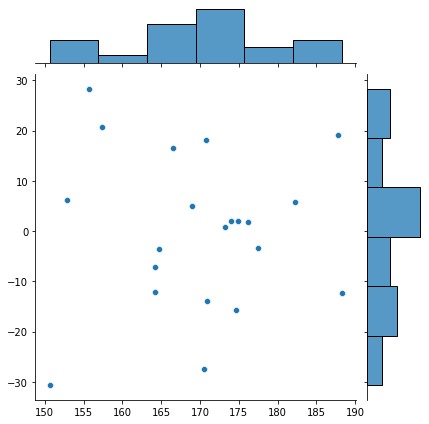

In [22]:
fig = sns.jointplot(fittedvalues, residuals)

Looks fine: the scatterplot clearly shows no structure, and the correlation is also 0.

### Homoscedasticity of residuals

The last assumption to be checked is that variance of the residuals is the same for all values of the predictors (`codelines`). We just need to plot the residuals against `codelines` to see if the values are more or less on the same scale:

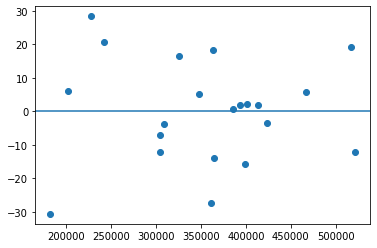

In [23]:
plt.plot(data.codelines, residuals, "o")
plt.axhline() # horizontal line

Basically, looks fine - no special tendencies can be seen. (Maybe the variance is higher at the beginning? But the sample size is to small to judge).

## Predictions

Predict bugfix time for 250.000 codelies (interpolation) and 600.000 codelines (extrapolation):

In [24]:
newdata = pd.DataFrame({'codelines' : [250000, 600000, 10000, 3000000]})
newdata

,codelines
0,250000
1,600000
2,10000
3,3000000


Just predict the expected values:

In [25]:
model.predict(newdata)

0    158.093959
1    197.039867
2    131.388193
3    464.097521
dtype: float64

To additionally get intervals for the *individual* predictions:

In [26]:
model.get_prediction(newdata).summary_frame()

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,158.093959,5.344247,146.908321,169.279597,122.937323,193.250595
1,197.039867,10.056658,175.991041,218.088693,157.620029,236.459705
2,131.388193,13.761635,102.584761,160.191626,87.336993,175.439394
3,464.097521,102.050573,250.503217,677.691826,247.918435,680.276608


# More than two variables

## Pairwise correlations

In [27]:
data.corr()

,dauer,codelines,usecases,alter
dauer,1.000000,0.551981,0.532579,0.119741
codelines,0.551981,1.000000,0.853550,-0.119431
usecases,0.532579,0.853550,1.000000,-0.023446
alter,0.119741,-0.119431,-0.023446,1.000000


In [28]:
sns.heatmap?

Signature:
sns.heatmap(
    data,
    *,
    vmin=None,
    vmax=None,
    cmap=None,
    center=None,
    robust=False,
    annot=None,
    fmt='.2g',
    annot_kws=None,
    linewidths=0,
    linecolor='white',
    cbar=True,
    cbar_kws=None,
    cbar_ax=None,
    square=False,
    xticklabels='auto',
    yticklabels='auto',
    mask=None,
    ax=None,
    **kwargs,
)
Docstring:
Plot rectangular data as a color-encoded matrix.

This is an Axes-level function and will draw the heatmap into the
currently-active Axes if none is provided to the ``ax`` argument.  Part of
this Axes space will be taken and used to plot a colormap, unless ``cbar``
is False or a separate Axes is provided to ``cbar_ax``.

Parameters
----------
data : rectangular dataset
    2D dataset that can be coerced into an ndarray. If a Pandas DataFrame
    is provided, the index/column information will be used to label the
    columns and rows.
vmin, vmax : floats, optional
    Values to anchor the colormap, otherwise

<AxesSubplot:>

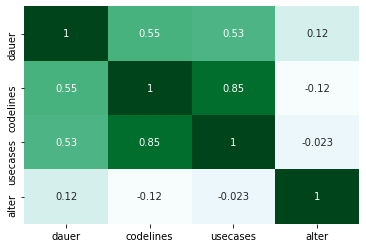

In [29]:
sns.heatmap(data.corr(), annot = True, cbar = False, cmap = "BuGn")

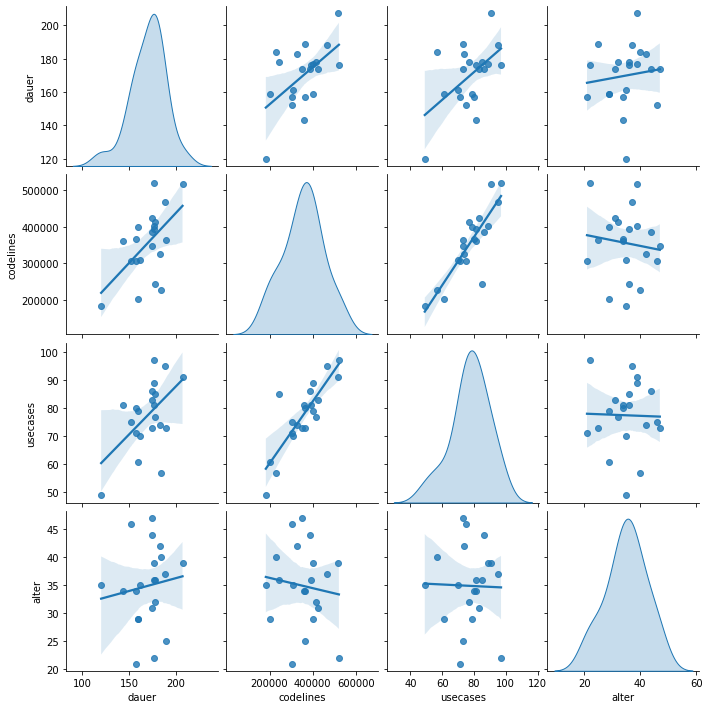

In [30]:
sns.pairplot(data, kind = "reg", diag_kind = "kde")

## Regression models with more than one predictor

In the regression formula, just add predictors with the `+` operator:

In [31]:
model2 = smf.ols(formula = "dauer ~ codelines + usecases", data = data).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  dauer   R-squared:                       0.319
Model:                            OLS   Adj. R-squared:                  0.243
Method:                 Least Squares   F-statistic:                     4.208
Date:                Thu, 22 Apr 2021   Prob (F-statistic):             0.0317
Time:                        14:56:06   Log-Likelihood:                -86.659
No. Observations:                  21   AIC:                             179.3
Df Residuals:                      18   BIC:                             182.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    116.7953     26.485      4.410      0.000      61.153     172.437
codelines   7.233e-05   7.53e-05      0.961      0.349   -8.58e-05       0.000
usecases       0.3526      0.582      0.606      0.552      -0.870       1.575
==============================================================================
Omnibus:                        0.003   Durbin-Watson:                   2.119
Prob(Omnibus):                  0.998   Jarque-Bera (JB):                0.183
Skew:                          -0.011   Prob(JB):                        0.913
Kurtosis:                       2.543   Cond. No.                     2.75e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.75e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""



# Linear Regression using scikit-learn

In [32]:
import numpy as np
from sklearn import linear_model


In [44]:
# define a regressor
regr = linear_model.LinearRegression()

# for convenience, create suitable arrays from data
_X = data.codelines.to_numpy().reshape(-1, 1)
_y = data.dauer.to_numpy().reshape(-1, 1)

# train regressor
regr.fit(_X, _y)

print('\nRegression coefficients:', regr.coef_)
print('Regression intersept:   ', regr.intercept_)
#    score 1 ... overfitted, 0 ... no relationship
#    should be 0.75 < score < 0.90
print('Regression score:       ', regr.score(_X, _y))
print('Estimator settings:     ', regr.get_params())
print()



Regression coefficients: [[0.00011127]]
Regression intersept:    [130.27545317]
Regression score:        0.30468254953646134
Estimator settings:      {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'normalize': False, 'positive': False}


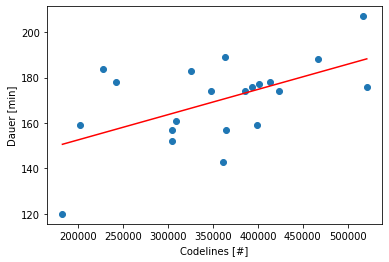

In [45]:
# plot linear regression
# compare to cell 20
reg_x = np.array([_X.min(), _X.max()])
reg_y = regr.predict(reg_x.reshape(-1, 1))

plt.scatter(_X, _y, marker='o')
plt.xlabel('Codelines [#]')
plt.ylabel('Dauer [min]')
plt.plot(reg_x, reg_y, c='red')
plt.show()

<AxesSubplot:xlabel='codelines', ylabel='dauer'>

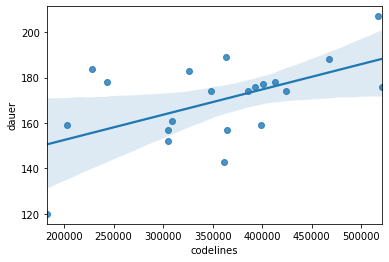

In [70]:
# abbreviation
sns.regplot(x='codelines', y='dauer', data=data[['codelines', 'dauer']])

## Regression formula

(compare to cell 22a)

In [35]:
print('\nE(dauer|codelines = {0:0.2f} + {1:0.4f} x codelines\n'.format(float(regr.intercept_), float(regr.coef_)))


E(dauer|codelines = 130.28 + 0.0001 x codelines



## LR with more than one feature

In [54]:
_X = data[['codelines', 'usecases']].to_numpy()
# _y ... dauer stays the same

regr2 = linear_model.LinearRegression().fit(_X, _y)

print('\nRegression coefficients:', regr2.coef_)
print('Regression intersept:   ', regr2.intercept_)
#    score 1 ... overfitted, 0 ... no relationship
#    should be 0.75 < score < 0.90
print('Regression score:       ', regr2.score(_X, _y))
print('Estimator settings:     ', regr2.get_params())
print()



Regression coefficients: [[7.23313977e-05 3.52572073e-01]]
Regression intersept:    [116.79527038]
Regression score:        0.31858677325802187
Estimator settings:      {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'normalize': False, 'positive': False}



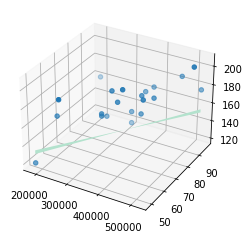

In [111]:
_x = data['codelines']
_y = data['usecases']
_z = data['dauer']

# BUG: fix this with meshgrid

_rx = np.array([data.codelines.min(), data.codelines.max()])
_ry = np.array([data.usecases.min(), data.usecases.max()])
_rz = np.array([
    [(regr2.intercept_ + data.codelines.min()*regr2.coef_[0][0])[0], 
    (regr2.intercept_ + data.codelines.max()*regr2.coef_[0][0])[0]], 
    [(regr2.intercept_ + data.usecases.min()*regr2.coef_[0][1])[0], 
    (regr2.intercept_ + data.usecases.max()*regr2.coef_[0][1])[0]]])

ax = plt.axes(projection='3d')
ax.scatter(_x, _y, _z)
ax.plot_surface(_rx, _ry, _rz, cmap='Pastel2')
plt.show()